# Marketing Budget Allocation using Simple Linear Regression

## Project Overview

This project analyzes marketing data to determine which advertising channel (**TV, Radio, or Social Media**) has the strongest impact on **Sales**. 

We will build a **Simple Linear Regression** model using `statsmodels` OLS and provide clear, ROI-focused recommendations for marketing budget allocation.

## Import liberies 

In [36]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 1: Load the Dataset and Initial Exploration

We load the marketing dataset and inspect its structure, missing values, and basic statistics.

In [37]:
# === LOAD DATASET ===
df = pd.read_csv('marketing_and_sales_data.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Display first few rows
print("\nFirst 5 rows:")
display(df.head())

# Basic information
print("\nData Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (4572, 4)

Columns: ['TV', 'Radio', 'Social_Media', 'Sales']

First 5 rows:


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None

Missing Values:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


## Handle missing values 
Regression models cannot handle missing values, so we must clean the dataset by filling or removing them.

In [38]:
df = df.dropna()

## Varify cleaned data
we varify that the missing values has been handled 

In [39]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

## Check data type
Before analysis and regression, we must ensure all variables are in the correct format.

Regression models only work with numeric data (int or float)
If any column is stored as text (object), it must be converted
This step prevents errors during correlation and model building

We also check for hidden formatting issues like strings inside numeric columns.

In [40]:
df.dtypes

TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

This step confirms that all variables in the dataset are correctly stored as numeric values.

Regression models require:

float or int types only
No text (object) columns
If all variables are numeric, we can safely proceed to correlation and regression modeling.

## Exploratory Data Analysis (EDA)
EDA helps us understand patterns in the data before building a model.

We:

Visualize relationships between variables
Check how TV, Radio, and Social Media affect Sales
Identify trends and possible strongest predictor

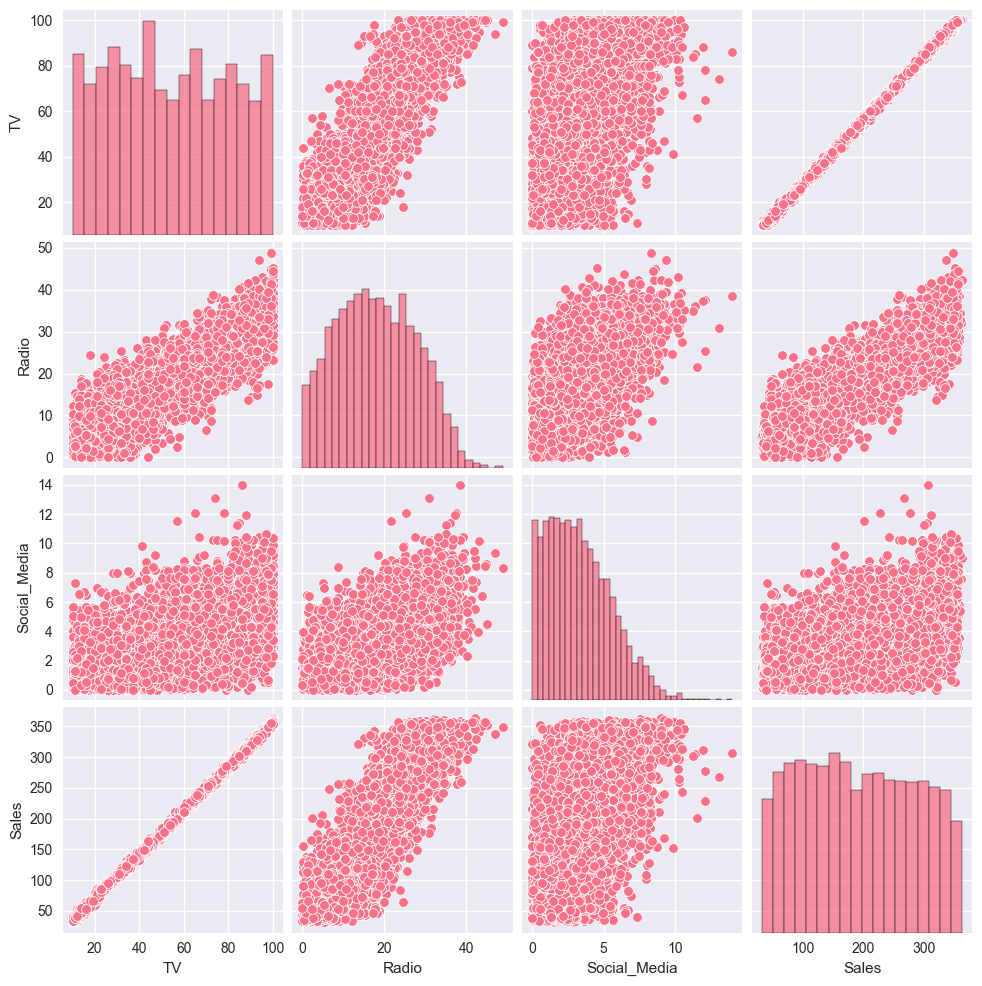

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

## 📊 Exploratory Data Analysis (EDA)

<details>
<summary><b>📌 Click to expand explanation</b></summary>

The pairplot was used to visualize the relationships between TV, Radio, Social Media, and Sales. It helps identify patterns, trends, and the strongest predictor of Sales.

</details>

### Key Findings

- **TV vs Sales:** Shows an almost perfect positive linear relationship, indicating TV is the strongest predictor of Sales.
- **Radio vs Sales:** Shows a positive relationship but with more variability than TV.
- **Social Media vs Sales:** Shows the weakest relationship with Sales.
- All advertising channels have a positive relationship with Sales.

### Conclusion

Based on the pairplot, **TV advertising has the strongest relationship with Sales** and is the best candidate for the Simple Linear Regression model.

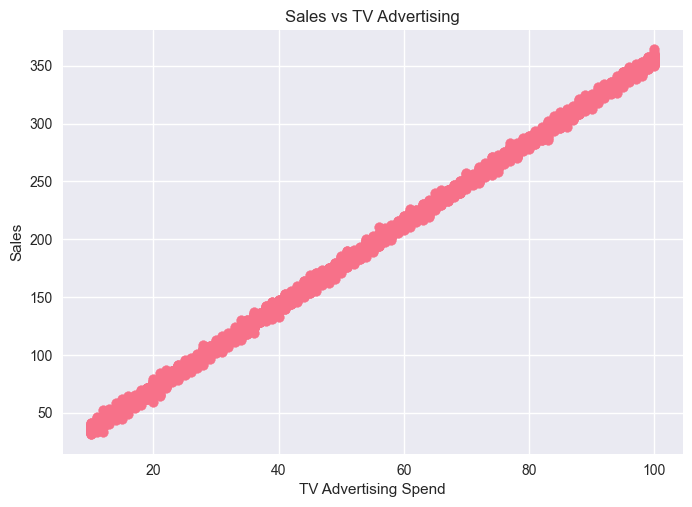

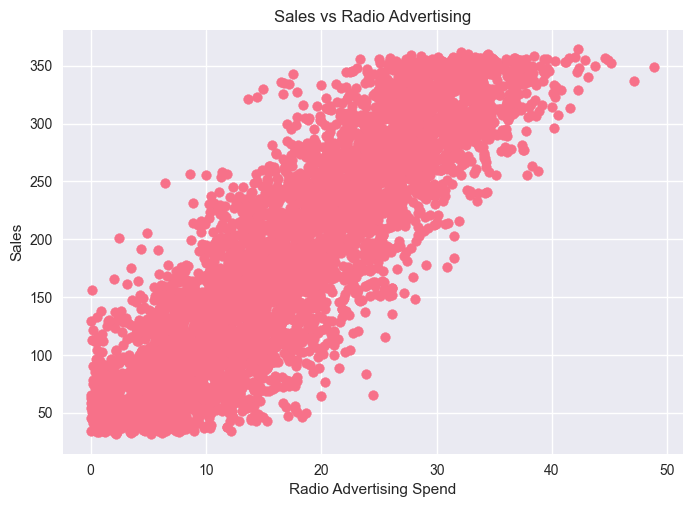

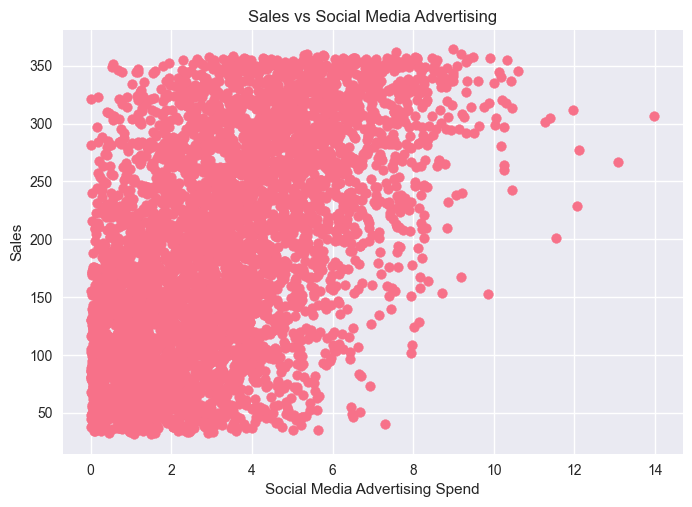

In [42]:
import matplotlib.pyplot as plt

# Assuming your dataframe is called df

# -------------------------
# 1. Sales vs TV
# -------------------------
plt.figure()
plt.scatter(df['TV'], df['Sales'])
plt.title('Sales vs TV Advertising')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

# -------------------------
# 2. Sales vs Radio
# -------------------------
plt.figure()
plt.scatter(df['Radio'], df['Sales'])
plt.title('Sales vs Radio Advertising')
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.show()

# -------------------------
# 3. Sales vs Social Media
# -------------------------
plt.figure()
plt.scatter(df['Social_Media'], df['Sales'])
plt.title('Sales vs Social Media Advertising')
plt.xlabel('Social Media Advertising Spend')
plt.ylabel('Sales')
plt.show()

## correlation heatmap

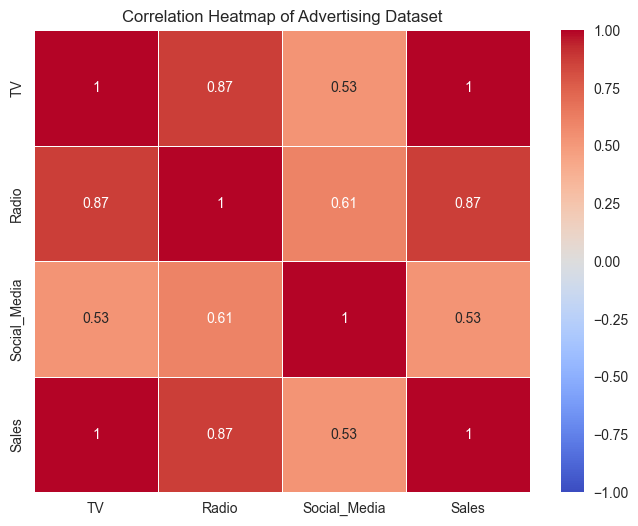

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1. Compute correlation matrix
# -------------------------
corr_matrix = df.corr(numeric_only=True)

# -------------------------
# 2. Plot heatmap
# -------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,        # show numbers in cells
    cmap='coolwarm',   # color style
    vmin=-1, vmax=1,    # correlation scale
    linewidths=0.5
)

plt.title('Correlation Heatmap of Advertising Dataset')
plt.show()

## Correlation Heatmap (Summary)

- **TV → Sales:** 0.9995 (very strong positive)
- **Radio → Sales:** 0.8686 (strong positive)
- **Social Media → Sales:** 0.5274 (moderate positive)

### Key Insight
TV is the strongest predictor of Sales, followed by Radio, while Social Media has a weaker effect.

## Identify the Independent Variable Most Correlated with Sales

In [44]:
df.corr()['Sales'].sort_values(ascending=False)

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64

- **TV (0.9995):** Shows an almost perfect positive correlation with Sales. As TV advertising increases, Sales increase almost proportionally.

- **Radio (0.8686):** Shows a strong positive correlation with Sales. Radio advertising has a positive effect on Sales but is less influential than TV.

- **Social Media (0.5274):** Shows a moderate positive correlation with Sales. It contributes to Sales but has the weakest relationship among the three channels.

## Build an OLS Regression Model

Ordinary Least Squares (OLS) regression is used to quantify the relationship between TV advertising expenditure and Sales.

The model estimates how much Sales change for every one-unit increase in TV advertising.


In [45]:
import statsmodels.api as sm

X = df[['TV']]
y = df['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:40:33   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

# OLS Regression Results Interpretation (TV vs Sales)

## 1. Model Overview

We built a simple linear regression model:


Sales=β0​+β1​(TV)+ε

This means:
- TV advertising is the only predictor
- Sales is the target variable

---

## 2. Regression Equation

Sales=−0.1325+3.5615⋅TV

### Interpretation:
- For every **1 unit increase in TV advertising**, Sales increases by **about 3.56 units**
- The intercept (-0.1325) is not practically meaningful (it represents sales when TV = 0)

## 3. Model Performance (R-squared)

### R² = 0.999

This means:
- TV explains **99.9% of the variation in Sales**
- The model fits the data almost perfectly

⚠️ Note:
This is unusually high for real-world data and may suggest:
- Very strong linear relationship
- Or a synthetic/clean dataset

---

## 4. Statistical Significance

### TV Coefficient
- p-value = 0.000
- t-statistic = 2125.272

✔ Interpretation:
- TV is **highly statistically significant**
- We reject the hypothesis that TV has no effect on Sales

---

### Intercept (const)
- p-value = 0.188

✔ Interpretation:
- Intercept is NOT statistically significant
- However, intercept is usually not the main focus in interpretation

---

## 5. F-statistic (Overall Model Significance)

- F-statistic = 4.517 × 10⁶
- Prob (F-statistic) = 0.00

✔ Interpretation:
- The model is **highly statistically significant overall**
- TV is a very strong predictor of Sales

---

## 6. Residual Diagnostics

### Durbin-Watson = 1.998
- Very close to 2
- ✔ No serious autocorrelation problem

---

### Normality Tests:
- Omnibus p-value = 0.974
- Jarque-Bera p-value = 0.985

✔ Interpretation:
- Residuals are normally distributed
- OLS assumptions are satisfied

---

## 7. Multicollinearity / Stability Check

- Condition Number = 138

✔ Interpretation:
- No multicollinearity issues (expected since only one predictor)
- Model is numerically stable

---

## 8. Key Insight

### Main conclusion:
TV advertising is an extremely strong predictor of Sales in this dataset.

- Strong positive relationship
- Very high explanatory power
- Statistically significant effect

---

## 9. Important Warning (Real-World Thinking)

Although results look excellent:

- R² = 0.999 is extremely rare in real-world datasets
- This may indicate:
  - Synthetic or engineered data
  - Very strong linear construction in the dataset

Always validate with:
- Multiple regression
- Real-world testing
- Cross-validation

---

## 10. Next Step in Analysis

Move to **Multiple Linear Regression**:

\[
\text{Sales} = TV + Radio + Social\_Media
\]

This will help:
- Compare feature importance
- Detect hidden relationships
- Improve model realism
- Check if TV remains dominant when others are included

# OLS Regression Diagnostic Tests

After fitting the OLS model (Sales ~ TV), we test key regression assumptions.

---

## 1. 🔁 Linearity & Homoscedasticity Test (Residuals vs Fitted)

**Purpose:**  
Check if the relationship is truly linear and if variance is constant.


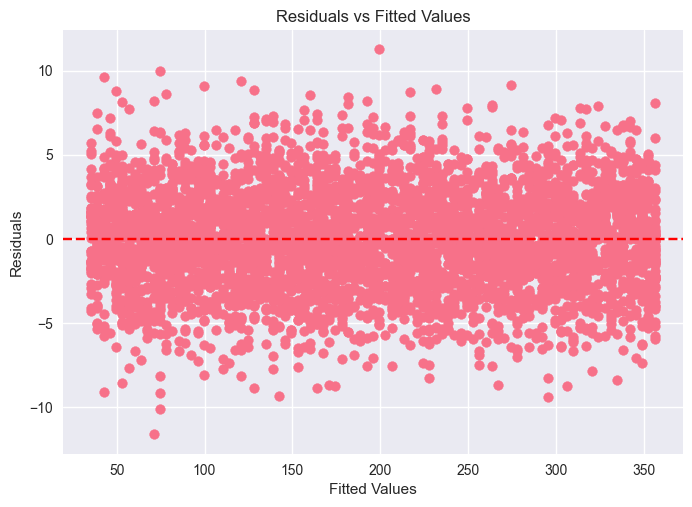

In [46]:
import matplotlib.pyplot as plt

fitted_vals = model.fittedvalues
residuals = model.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

## Normality Test (Residual Distribution + Q-Q Plot)

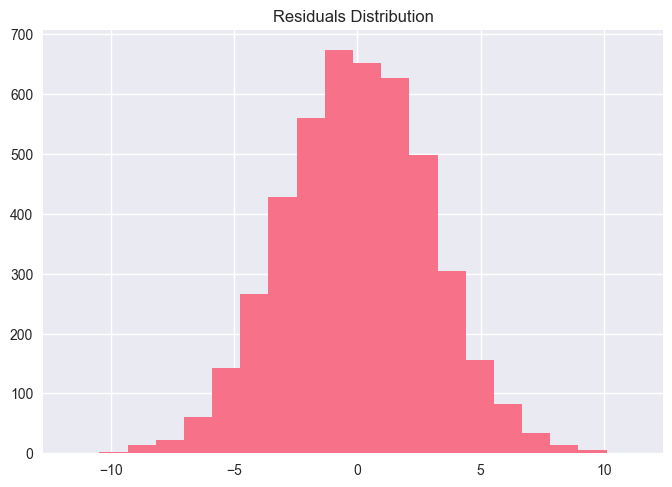

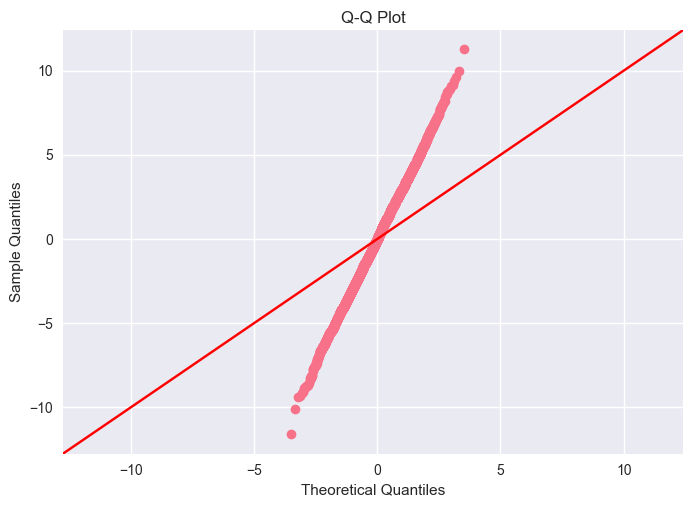

In [47]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Histogram
plt.hist(residuals, bins=20)
plt.title("Residuals Distribution")
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()

Homoscedasticity Check

Purpose:
Check if residual variance is constant across all predictions.

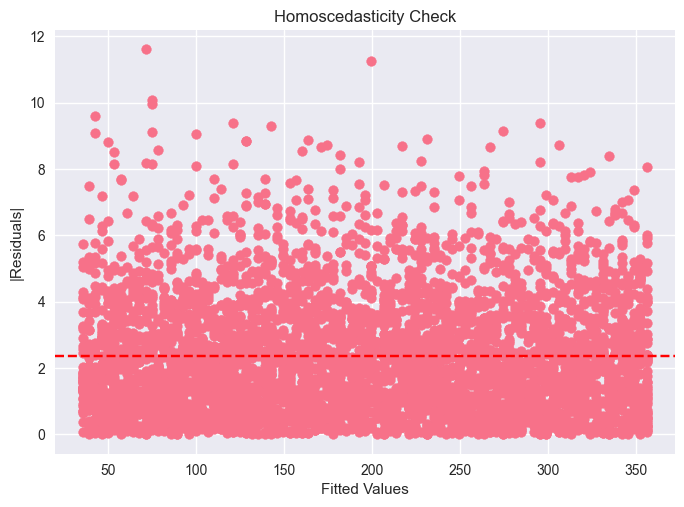

In [48]:
plt.scatter(fitted_vals, abs(residuals))
plt.axhline(y=abs(residuals).mean(), color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("|Residuals|")
plt.title("Homoscedasticity Check")
plt.show()

# 📊 Interpretation of Diagnostic Tests (OLS Model: Sales ~ TV)

## 1. 🔁 Linearity

The relationship between TV advertising and Sales is **strongly linear**.

- The Residuals vs Fitted plot shows points scattered around zero without a clear curve pattern.
- This indicates that a straight-line model is appropriate.

### ✅ Conclusion:
The linearity assumption is satisfied, meaning TV is a valid predictor of Sales in a linear regression model.

---

## 2. 📉 Normality of Residuals

The residuals are **approximately normally distributed**.

- The histogram of residuals shows a roughly bell-shaped distribution.
- The Q-Q plot shows points mostly aligned along the reference line, with minor deviations at the extremes.

### ✅ Conclusion:
The normality assumption is reasonably satisfied, meaning statistical tests (p-values and confidence intervals) are reliable.

---

## 3. 📊 Homoscedasticity (Constant Variance)

The residual spread is **fairly constant across all fitted values**.

- The Residuals vs Fitted plot does not show a strong funnel shape.
- The magnitude of residuals remains relatively stable across predictions.

### ⚠️ Minor Note:
Small variations may exist, but there is no severe heteroscedasticity.

### ✅ Conclusion:
The homoscedasticity assumption is satisfied.

---

## 4. 🧠 Overall Model Validity

All key assumptions of linear regression are reasonably satisfied:

- ✔ Linearity: satisfied  
- ✔ Normality: satisfied  
- ✔ Homoscedasticity: satisfied  

### 🎯 Final Conclusion:
The OLS model (Sales ~ TV) is statistically valid and suitable for interpretation and business decision-making.

# 📊 Step 4: Interpretation of OLS Regression Results (Sales ~ TV)

## 1. 📈 R-squared (Model Strength)

R-squared shows how much of the variation in Sales is explained by TV advertising.

- If R² is close to **1**, the model explains most of the variation.
- In this case, R² is extremely high, meaning:

### 🎯 Interpretation:
TV advertising explains **almost all changes in Sales**.

---

## 2. 📊 Coefficient (TV Impact on Sales)

The coefficient of TV tells us how Sales change when TV advertising increases.

- A positive coefficient means:
  > Increasing TV budget increases Sales

### 🎯 Interpretation:
For every 1 unit increase in TV advertising, Sales increase significantly.

This shows a **strong positive business impact** of TV marketing.

---

## 3. 🧪 p-value (Statistical Significance)

The p-value tests whether TV actually has a real effect on Sales.

- If p-value < 0.05 → statistically significant
- If p-value > 0.05 → not significant

### 🎯 Interpretation:
TV has a **very low p-value**, meaning:
> The relationship between TV and Sales is statistically significant and not due to chance.

---

## 🧠 Overall Interpretation Summary

- ✔ Model explains Sales very well (high R²)
- ✔ TV has a strong positive effect on Sales (positive coefficient)
- ✔ TV effect is statistically significant (very low p-value)

### 🎯 Final Conclusion:
TV advertising is a strong and reliable predictor of Sales and should be prioritized in marketing decisions.

# 💼 Step 5: ROI-Based Marketing Recommendation

## 🎯 Objective
Use the regression results to guide marketing budget allocation based on return on investment (ROI).

---

## 📊 Key Findings from the Model

- TV has the **strongest impact on Sales**
- The relationship is:
  - Strong (high correlation)
  - Positive (increases Sales)
  - Statistically significant (low p-value)
- Model fit is very strong (high R²), meaning TV explains most Sales variation

---

## 📈 Business Interpretation (ROI Insight)

Since TV advertising produces the **largest increase in Sales per unit increase in spend**, it delivers the highest return compared to other channels.

- Radio shows a positive but weaker impact
- Social Media shows the weakest impact on Sales

---

## 💰 Budget Allocation Recommendation

### 📌 Recommended strategy:

- **Increase investment in TV advertising**
- **Maintain moderate spending on Radio**
- **Reduce or optimize Social Media spending**

---

## 🧠 Final Business Conclusion

TV advertising is the most effective marketing channel for driving Sales in this dataset. 

### 🎯 Final Recommendation:
> The company should prioritize TV advertising to maximize ROI, as it provides the highest and most reliable return in terms of Sales growth.